In [57]:
import pandas as pd
import numpy as np

In [58]:
df = pd.read_csv("HousePricePrediction.csv")

In [59]:
df.shape

(2919, 13)

In [60]:
df.info

<bound method DataFrame.info of         Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0        0          60       RL     8450    Inside     1Fam            5   
1        1          20       RL     9600       FR2     1Fam            8   
2        2          60       RL    11250    Inside     1Fam            5   
3        3          70       RL     9550    Corner     1Fam            5   
4        4          60       RL    14260       FR2     1Fam            5   
...    ...         ...      ...      ...       ...      ...          ...   
2914  2914         160       RM     1936    Inside    Twnhs            7   
2915  2915         160       RM     1894    Inside   TwnhsE            5   
2916  2916          20       RL    20000    Inside     1Fam            7   
2917  2917          85       RL    10441    Inside     1Fam            5   
2918  2918          60       RL     9627    Inside     1Fam            5   

      YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  

In [61]:
df.columns


Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2',
       'TotalBsmtSF', 'SalePrice'],
      dtype='object')

In [62]:
df.sample(10)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
808,808,80,RL,13400,Inside,1Fam,5,1966,1966,VinylSd,128.0,1024.0,159950.0
686,686,60,FV,10207,Inside,1Fam,6,2007,2007,VinylSd,0.0,874.0,227875.0
1739,1739,120,FV,3830,Inside,TwnhsE,5,2008,2008,VinylSd,0.0,1726.0,NaN
2578,2578,50,RM,11067,Corner,1Fam,4,1939,1950,MetalSd,0.0,0.0,NaN
2706,2706,20,RL,8638,Inside,1Fam,6,1963,1963,HdBoard,0.0,925.0,NaN
2708,2708,20,RL,8020,Inside,1Fam,6,1964,1964,HdBoard,0.0,912.0,NaN
1018,1018,80,RL,10784,FR2,1Fam,5,1991,1992,HdBoard,0.0,384.0,160000.0
2572,2572,20,RL,20693,Corner,1Fam,5,1971,1971,Plywood,0.0,1696.0,NaN
310,310,60,RL,7685,Inside,1Fam,5,1993,1994,HdBoard,0.0,697.0,165600.0
1450,1450,90,RL,9000,FR2,Duplex,5,1974,1974,VinylSd,0.0,896.0,136000.0


<Axes: xlabel='BldgType', ylabel='SalePrice'>

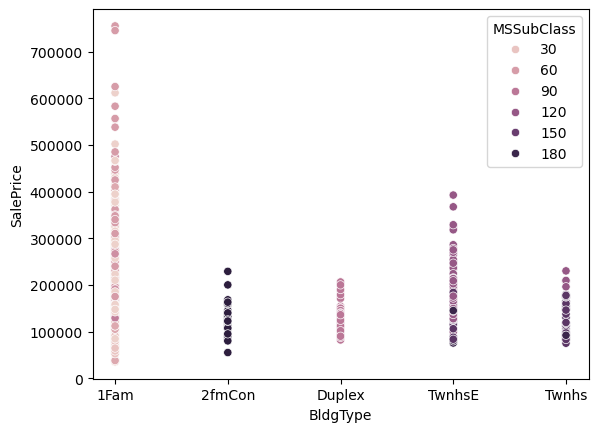

In [63]:
import seaborn as sns

sns.scatterplot(y=df['SalePrice'],x=df['BldgType'],hue=df['MSSubClass'])

In [64]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [65]:
df.dropna

<bound method DataFrame.dropna of         Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0        0          60       RL     8450    Inside     1Fam            5   
1        1          20       RL     9600       FR2     1Fam            8   
2        2          60       RL    11250    Inside     1Fam            5   
3        3          70       RL     9550    Corner     1Fam            5   
4        4          60       RL    14260       FR2     1Fam            5   
...    ...         ...      ...      ...       ...      ...          ...   
2914  2914         160       RM     1936    Inside    Twnhs            7   
2915  2915         160       RM     1894    Inside   TwnhsE            5   
2916  2916          20       RL    20000    Inside     1Fam            7   
2917  2917          85       RL    10441    Inside     1Fam            5   
2918  2918          60       RL     9627    Inside     1Fam            5   

      YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2

In [69]:
# Adjust the column names to match the one-hot encoded columns
cols = [col for col in df.columns if col.startswith(('MSZoning', 'LotConfig', 'BldgType', 'Exterior1st'))]
df = df.drop(columns=cols)

In [67]:
df.shape

(2919, 35)

In [70]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),
                                                 df['SalePrice'],
                                                 test_size=0.2,
                                                random_state=42)

In [72]:
from sklearn.linear_model import LinearRegression

from sklearn.impute import SimpleImputer

imputer_X = SimpleImputer(strategy='mean')
X_train = pd.DataFrame(imputer_X.fit_transform(X_train), columns=X_train.columns)

# Handle missing values in y_train
y_train = y_train.fillna(y_train.mean())

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [74]:
predictions = model.predict(X_test)

In [78]:
X_test.shape

(584, 8)

In [83]:
from sklearn.metrics import mean_squared_error

# Drop NaN values from y_test and align predictions
y_test_clean = y_test.dropna()
predictions_clean = pd.Series(predictions, index=X_test.index).loc[y_test_clean.index]

print("RMSE:", np.sqrt(mean_squared_error(y_test_clean, predictions_clean)))

RMSE: 64507.812140915004
